#  Loan Approval Prediction using Machine Learning


# Objective

## The objective of this project is to predict whether a loan application will be approved or rejected using Machine Learning algorithms.

# Import Libraries

In [2]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix
)

Matplotlib is building the font cache; this may take a moment.


# Load Dataset

In [5]:
df = pd.read_csv("loan_approval_dataset.csv")
df.head()

,loan_id,no_of_dependents,education,self_employed,income_annum,loan_amount,loan_term,cibil_score,residential_assets_value,commercial_assets_value,luxury_assets_value,bank_asset_value,loan_status
0,1,2,Graduate,No,9600000,29900000,12,778,2400000,17600000,22700000,8000000,Approved
1,2,0,Not Graduate,Yes,4100000,12200000,8,417,2700000,2200000,8800000,3300000,Rejected
2,3,3,Graduate,No,9100000,29700000,20,506,7100000,4500000,33300000,12800000,Rejected
3,4,3,Graduate,No,8200000,30700000,8,467,18200000,3300000,23300000,7900000,Rejected
4,5,5,Not Graduate,Yes,9800000,24200000,20,382,12400000,8200000,29400000,5000000,Rejected


# Dataset Shape

In [6]:
print("Rows and Columns:", df.shape)

Rows and Columns: (4269, 13)


# Column Names

In [7]:
df.columns

Index(['loan_id', ' no_of_dependents', ' education', ' self_employed',
       ' income_annum', ' loan_amount', ' loan_term', ' cibil_score',
       ' residential_assets_value', ' commercial_assets_value',
       ' luxury_assets_value', ' bank_asset_value', ' loan_status'],
      dtype='str')

# Data Types

In [8]:
df.dtypes

loan_id                      int64
 no_of_dependents            int64
 education                     str
 self_employed                 str
 income_annum                int64
 loan_amount                 int64
 loan_term                   int64
 cibil_score                 int64
 residential_assets_value    int64
 commercial_assets_value     int64
 luxury_assets_value         int64
 bank_asset_value            int64
 loan_status                   str
dtype: object

# Check Missing Values

In [9]:
df.isnull().sum()

loan_id                      0
 no_of_dependents            0
 education                   0
 self_employed               0
 income_annum                0
 loan_amount                 0
 loan_term                   0
 cibil_score                 0
 residential_assets_value    0
 commercial_assets_value     0
 luxury_assets_value         0
 bank_asset_value            0
 loan_status                 0
dtype: int64

 # Dataset  Information

In [10]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 4269 entries, 0 to 4268
Data columns (total 13 columns):
 #   Column                     Non-Null Count  Dtype
---  ------                     --------------  -----
 0   loan_id                    4269 non-null   int64
 1    no_of_dependents          4269 non-null   int64
 2    education                 4269 non-null   str  
 3    self_employed             4269 non-null   str  
 4    income_annum              4269 non-null   int64
 5    loan_amount               4269 non-null   int64
 6    loan_term                 4269 non-null   int64
 7    cibil_score               4269 non-null   int64
 8    residential_assets_value  4269 non-null   int64
 9    commercial_assets_value   4269 non-null   int64
 10   luxury_assets_value       4269 non-null   int64
 11   bank_asset_value          4269 non-null   int64
 12   loan_status               4269 non-null   str  
dtypes: int64(10), str(3)
memory usage: 433.7 KB


# Statistical Summary

In [11]:
df.describe()

,loan_id,no_of_dependents,income_annum,loan_amount,loan_term,cibil_score,residential_assets_value,commercial_assets_value,luxury_assets_value,bank_asset_value
count,4269.000000,4269.000000,4.269000e+03,4.269000e+03,4269.000000,4269.000000,4.269000e+03,4.269000e+03,4.269000e+03,4.269000e+03
mean,2135.000000,2.498712,5.059124e+06,1.513345e+07,10.900445,599.936051,7.472617e+06,4.973155e+06,1.512631e+07,4.976692e+06
std,1232.498479,1.695910,2.806840e+06,9.043363e+06,5.709187,172.430401,6.503637e+06,4.388966e+06,9.103754e+06,3.250185e+06
min,1.000000,0.000000,2.000000e+05,3.000000e+05,2.000000,300.000000,-1.000000e+05,0.000000e+00,3.000000e+05,0.000000e+00
25%,1068.000000,1.000000,2.700000e+06,7.700000e+06,6.000000,453.000000,2.200000e+06,1.300000e+06,7.500000e+06,2.300000e+06
50%,2135.000000,3.000000,5.100000e+06,1.450000e+07,10.000000,600.000000,5.600000e+06,3.700000e+06,1.460000e+07,4.600000e+06
75%,3202.000000,4.000000,7.500000e+06,2.150000e+07,16.000000,748.000000,1.130000e+07,7.600000e+06,2.170000e+07,7.100000e+06
max,4269.000000,5.000000,9.900000e+06,3.950000e+07,20.000000,900.000000,2.910000e+07,1.940000e+07,3.920000e+07,1.470000e+07


#  Remove Extra Spaces from Column Names

In [12]:
df.columns = df.columns.str.strip()

df.columns

Index(['loan_id', 'no_of_dependents', 'education', 'self_employed',
       'income_annum', 'loan_amount', 'loan_term', 'cibil_score',
       'residential_assets_value', 'commercial_assets_value',
       'luxury_assets_value', 'bank_asset_value', 'loan_status'],
      dtype='str')

#  Check Duplicate Records

In [14]:
print("Duplicate Rows:", df.duplicated().sum())


Duplicate Rows: 0


# Remove Duplicates

In [13]:
df = df.drop_duplicates()

# Handle Missing Values

In [15]:
df = df.fillna(df.mode().iloc[0])

#  Encode Target Column

In [16]:
le = LabelEncoder()

df['loan_status'] = le.fit_transform(df['loan_status'])

df.head()

,loan_id,no_of_dependents,education,self_employed,income_annum,loan_amount,loan_term,cibil_score,residential_assets_value,commercial_assets_value,luxury_assets_value,bank_asset_value,loan_status
0,1,2,Graduate,No,9600000,29900000,12,778,2400000,17600000,22700000,8000000,0
1,2,0,Not Graduate,Yes,4100000,12200000,8,417,2700000,2200000,8800000,3300000,1
2,3,3,Graduate,No,9100000,29700000,20,506,7100000,4500000,33300000,12800000,1
3,4,3,Graduate,No,8200000,30700000,8,467,18200000,3300000,23300000,7900000,1
4,5,5,Not Graduate,Yes,9800000,24200000,20,382,12400000,8200000,29400000,5000000,1


# Correlation Heatmap

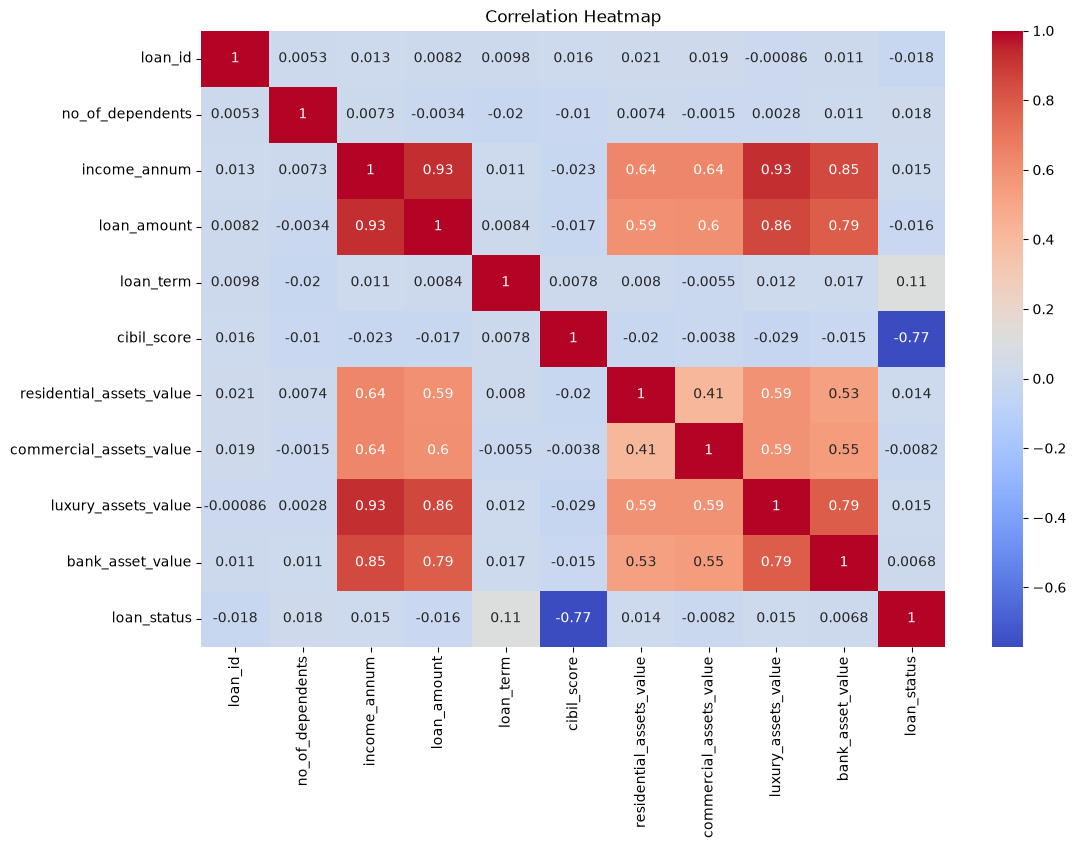

In [17]:
plt.figure(figsize=(12,8))

sns.heatmap(df.corr(numeric_only=True),
            annot=True,
            cmap="coolwarm")

plt.title("Correlation Heatmap")
plt.show()

#  Loan Status Analysis

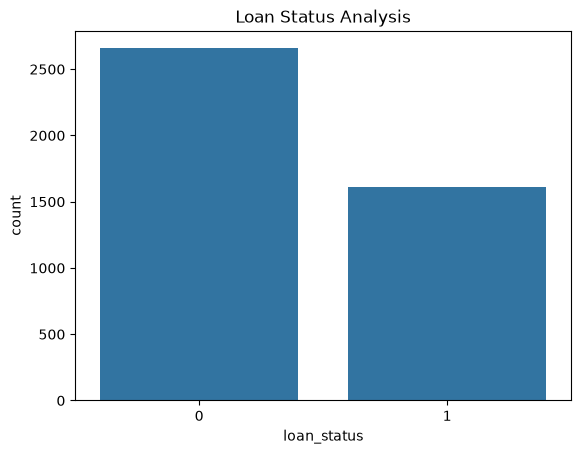

In [18]:
sns.countplot(x='loan_status', data=df)

plt.title("Loan Status Analysis")
plt.show()

# Income Distribution

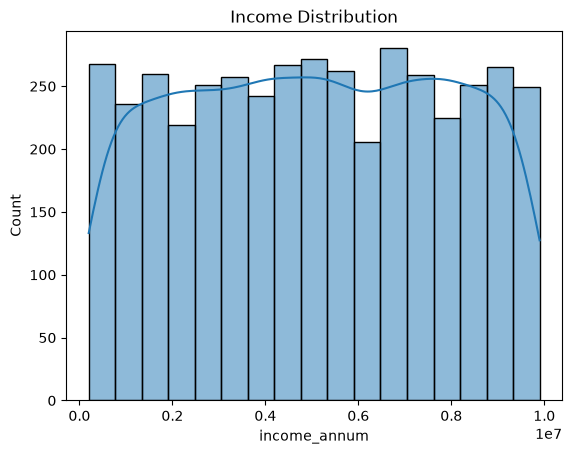

In [19]:
sns.histplot(df['income_annum'], kde=True)

plt.title("Income Distribution")
plt.show()

# Loan Amount Distribution|

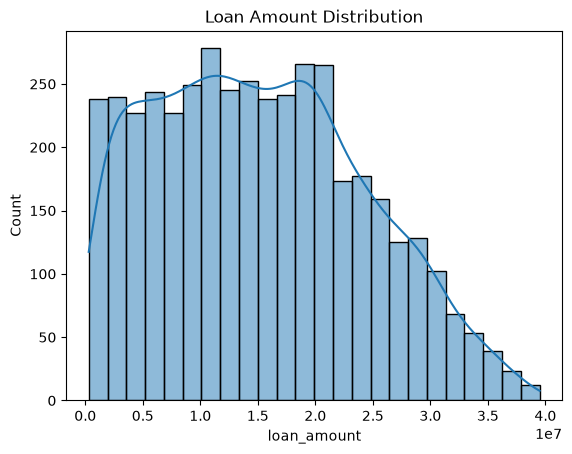

In [20]:
sns.histplot(df['loan_amount'], kde=True)

plt.title("Loan Amount Distribution")
plt.show()

# Income vs Loan Approval

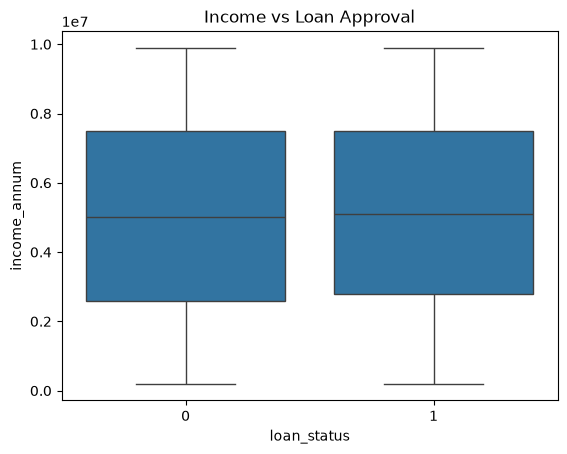

In [21]:
sns.boxplot(
    x='loan_status',
    y='income_annum',
    data=df
)

plt.title("Income vs Loan Approval")
plt.show()

# CIBIL Score Distribution

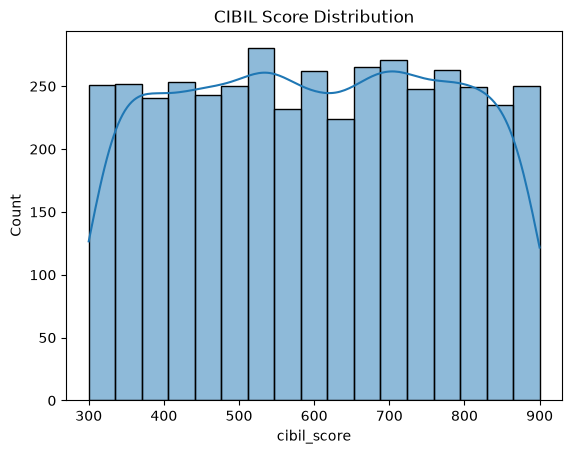

In [22]:
sns.histplot(df['cibil_score'], kde=True)

plt.title("CIBIL Score Distribution")
plt.show()

#  Label Encoding

In [26]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

for col in df.select_dtypes(include='object').columns:
    df[col] = le.fit_transform(df[col].astype(str))

C:\Users\fattani computer\AppData\Local\Temp\ipykernel_15416\3207929033.py:5: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  for col in df.select_dtypes(include='object').columns:


# Feature Scaling

In [27]:
X = df.drop('loan_status', axis=1)
y = df['loan_status']

#  Train Test Split

In [28]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

# Scaling

In [ ]:
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

#  Logistic Regression

In [29]:
lr = LogisticRegression()

lr.fit(X_train, y_train)

lr_pred = lr.predict(X_test)

c:\Users\fattani computer\OneDrive\Desktop\Loan_Approval_Prediction\venv\Lib\site-packages\sklearn\linear_model\_logistic.py:599: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


# Decision Tree

In [30]:
dt = DecisionTreeClassifier()

dt.fit(X_train, y_train)

dt_pred = dt.predict(X_test)

# Random Forest

In [31]:
rf = RandomForestClassifier()

rf.fit(X_train, y_train)

rf_pred = rf.predict(X_test)

#  Model Evaluation Function

In [32]:
def evaluate(y_test, pred):

    print("Accuracy:",
          accuracy_score(y_test, pred))

    print("Precision:",
          precision_score(y_test, pred))

    print("Recall:",
          recall_score(y_test, pred))

    print("F1 Score:",
          f1_score(y_test, pred))

# Logistic Regression Results

In [33]:
print("Logistic Regression")

evaluate(y_test, lr_pred)

Logistic Regression
Accuracy: 0.6323185011709602
Precision: 0.5303030303030303
Recall: 0.11006289308176101
F1 Score: 0.18229166666666666


# Decision Tree Results

In [34]:
print("Decision Tree")

evaluate(y_test, dt_pred)

Decision Tree
Accuracy: 0.9730679156908665
Precision: 0.9623824451410659
Recall: 0.9654088050314465
F1 Score: 0.9638932496075353


# Random Forest Results

In [35]:
print("Random Forest")

evaluate(y_test, rf_pred)

Random Forest
Accuracy: 0.9742388758782201
Precision: 0.9743589743589743
Recall: 0.9559748427672956
F1 Score: 0.9650793650793651


# Confusion Matrix

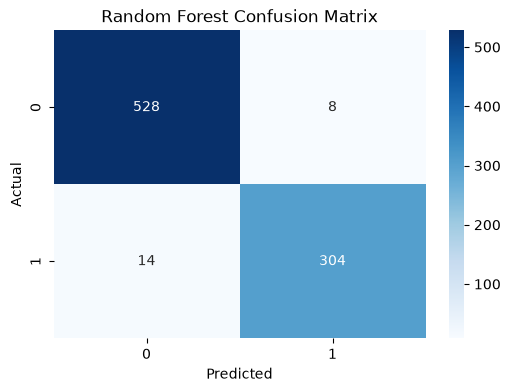

In [38]:
cm = confusion_matrix(y_test, rf_pred)

plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')

plt.title("Random Forest Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

#  Model Comparison Table

In [40]:
results = pd.DataFrame({
    'Model': ['Logistic Regression', 'Decision Tree', 'Random Forest'],
    'Accuracy': [
        accuracy_score(y_test, lr_pred),
        accuracy_score(y_test, dt_pred),
        accuracy_score(y_test, rf_pred)
    ],
    'Precision': [
        precision_score(y_test, lr_pred),
        precision_score(y_test, dt_pred),
        precision_score(y_test, rf_pred)
    ],
    'Recall': [
        recall_score(y_test, lr_pred),
        recall_score(y_test, dt_pred),
        recall_score(y_test, rf_pred)
    ],
    'F1 Score': [
        f1_score(y_test, lr_pred),
        f1_score(y_test, dt_pred),
        f1_score(y_test, rf_pred)
    ]
})

results

,Model,Accuracy,Precision,Recall,F1 Score
0,Logistic Regression,0.632319,0.530303,0.110063,0.182292
1,Decision Tree,0.973068,0.962382,0.965409,0.963893
2,Random Forest,0.974239,0.974359,0.955975,0.965079


# Best Model

In [41]:
best_model = results.loc[
    results['Accuracy'].idxmax()
]

best_model

Model        Random Forest
Accuracy          0.974239
Precision         0.974359
Recall            0.955975
F1 Score          0.965079
Name: 2, dtype: object

# Conclusion

### In this project, different Machine Learning algorithms were used to predict loan approval status. After preprocessing the dataset and training multiple models, the best-performing model was selected based on evaluation metrics. This project demonstrates the complete Machine Learning workflow from data preprocessing to model evaluation.